---
title: "Cercha"
author: "Tomas Gonzalez Llarena"
format:
  pdf:
    echo: false          # Hides all code cells
    warning: false       # Hides python warnings
    output: true         # Shows the results/plots
    pdf-engine: lualatex
    # mainfont: Arial
    keep-tex: false      # Cleans up temp LaTeX files
---



In [1]:
import math

# 1. GEOMETRY
# Horizontal distances from Support A (x=0)
x_A = 0.0
x_E = 1.5
x_B = 3.0
x_F = 4.5
x_C = 6.0
x_G = 7.5
x_D = 9.0

# Vertical depth of the truss
h = 1.5

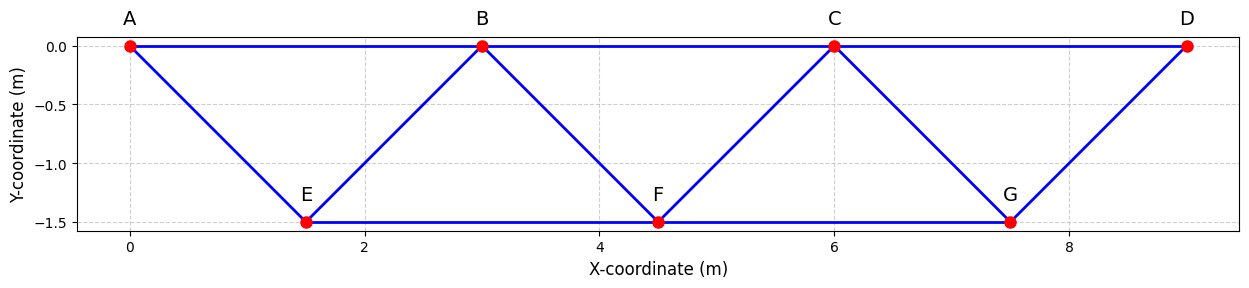

In [2]:
# PLOT TRUSS GEOMETRY
import matplotlib.pyplot as plt

# Define Nodo Coordinates based on variables from Cell 1
nodes = {
    'A': (x_A, 0),
    'E': (x_E, -h), 'F': (x_F, -h), 'G': (x_G, -h),
    'D': (x_D, 0),
    'B': (x_B, 0), 'C': (x_C, 0)
}

# Define Truss Members (Bars)
# This structure is inferred from the context of the calculations
bars = [
    ('E', 'F'), ('F', 'G'),  # Bottom Chord
    ('B', 'C'),    ('C', 'D'),                            # Top Chord
    ('A', 'B'),
    ('A', 'E'), ('E', 'B'), ('B', 'F'), ('F', 'C'), ('C', 'G'), ('G', 'D') # Web Members
]

# Create the plot
plt.figure(figsize=(15, 5))
ax = plt.gca()

# Plot bars
for bar in bars:
    x1, y1 = nodes[bar[0]]
    x2, y2 = nodes[bar[1]]
    plt.plot([x1, x2], [y1, y2], 'b-', linewidth=2)

# Plot nodes (joints)
for name, (x, y) in nodes.items():
    plt.plot(x, y, 'ro', markersize=8)
    plt.text(x, y + 0.15, name, fontsize=14, ha='center', va='bottom')

# Customize the plot
ax.set_aspect('equal', adjustable='box')
#plt.title('Truss Geometry and Nodo Labels', fontsize=16)
plt.xlabel('X-coordinate (m)', fontsize=12)
plt.ylabel('Y-coordinate (m)', fontsize=12)
plt.grid(linestyle='--', alpha=0.6)

plt.savefig('../img/truss_geometry.png', dpi=300)

plt.show()




In [18]:
# 2. EXTERNAL LOADS (in kN)
# Downward loads on the bottom chord
F_Ey = -60.0
F_Fy = -200.0
F_Gy = -100.0

# Angled 200 kN loads at B and C (70 degrees)
# Pointing downwards and leftwards
P_skew = 200.0
angle_rad = math.radians(70)

# Decomposing into X and Y components
F_Bx = -P_skew * math.cos(angle_rad)
F_By = -P_skew * math.sin(angle_rad)

F_Cx = -P_skew * math.cos(angle_rad)
F_Cy = -P_skew * math.sin(angle_rad)

print("--- CARGAS EXTERNAS CALCULADAS ---")
print(f"Nodo B -> Fx: {F_Bx:.2f} kN | Fy: {F_By:.2f} kN")
print(f"Nodo C -> Fx: {F_Cx:.2f} kN | Fy: {F_Cy:.2f} kN")

--- CARGAS EXTERNAS CALCULADAS ---
Node B -> Fx: -68.40 kN | Fy: -187.94 kN
Node C -> Fx: -68.40 kN | Fy: -187.94 kN


In [4]:
# 3. GLOBAL REACTIONS
# To find R_Ay, we take the sum of moments around Support D (x = 9.0)
# Counter-clockwise moments are considered positive.
# Lever arm is the horizontal distance from the load to Support D: (x_D - x_load)

# Sum of Moments about D = 0
moment_E = abs(F_Ey) * (x_D - x_E)
moment_B = abs(F_By) * (x_D - x_B)
moment_F = abs(F_Fy) * (x_D - x_F)
moment_C = abs(F_Cy) * (x_D - x_C)
moment_G = abs(F_Gy) * (x_D - x_G)

# The horizontal forces at B and C act along the top chord (y=0),
# which passes directly through D (y=0), so they create zero moment.
total_CCW_moment = moment_E + moment_B + moment_F + moment_C + moment_G

# R_Ay creates a clockwise (negative) moment with a lever arm of 9.0m
# R_Ay * 9.0 = total_CCW_moment
R_Ay = total_CCW_moment / x_D

# Sum of forces in X = 0
# The pinned support A takes all the horizontal thrust
R_Ax = -(F_Bx + F_Cx)

# Sum of forces in Y = 0 to find the roller reaction at D (R_Dy)
# Upward forces + Downward forces = 0
total_downward_Fy = F_Ey + F_By + F_Fy + F_Cy + F_Gy
R_Dy = -total_downward_Fy - R_Ay

print("--- REACCIONES DE SOPORTE GLOBAL ---")
print(f"Reacción at A (X-dir): R_Ax = {R_Ax:.2f} kN")
print(f"Reacción at A (Y-dir): R_Ay = {R_Ay:.2f} kN")
print(f"Reacción at D (Y-dir): R_Dy = {R_Dy:.2f} kN")

# Quick equilibrium check
equilibrium_check = R_Ay + R_Dy + total_downward_Fy
# print(f"Vertical Equilibrium Check (should be 0): {equilibrium_check:.4f}")

--- GLOBAL SUPPORT REACTIONS ---
Reaction at A (X-dir): R_Ax = 136.81 kN
Reaction at A (Y-dir): R_Ay = 354.61 kN
Reaction at D (Y-dir): R_Dy = 381.27 kN
Vertical Equilibrium Check (should be 0): 0.0000


In [5]:
# 4. METHOD OF SECTIONS (Calculating Force in Bar EF)
# We make a vertical cut through bars BC, BF, and EF.
# We analyze the left portion of the truss and sum moments about Nodo B.
# We assume N_EF is in TENSION (pulling to the right from Nodo E).

# Calculate lever arms relative to Nodo B (x=3.0, y=0.0)
lever_arm_RAy = x_B - x_A  # 3.0m (horizontal distance from A to B)
lever_arm_FEy = x_B - x_E  # 1.5m (horizontal distance from E to B)
lever_arm_NEF = h          # 1.5m (vertical distance from E to B)

# Sum of Moments about Nodo B = 0 (Counter-Clockwise is Positive)
# 1. Reacción A pushes UP from the left -> Creates Clockwise moment (-)
moment_RAy = -R_Ay * lever_arm_RAy

# 2. Load at E pulls DOWN from the left -> Creates Counter-Clockwise moment (+)
moment_FEy = abs(F_Ey) * lever_arm_FEy

# 3. Force N_EF pulls RIGHT from the bottom -> Creates Counter-Clockwise moment (+)
# The equation is: moment_RAy + moment_FEy + (N_EF * lever_arm_NEF) = 0

# Solving the equation algebraically for N_EF:
N_EF = -(moment_RAy + moment_FEy) / lever_arm_NEF

print("--- FUERZAS INTERNAS (MÉTODO DE SECCIONES) ---")
print(f"Axial Force in Bar EF (N_Ed): {N_EF:.2f} kN")

if N_EF > 0:
    print("Status: TENSION (Tracción)")
else:
    print("Status: COMPRESION (Compresión)")

--- INTERNAL FORCES (METHOD OF SECTIONS) ---
Axial Force in Bar EF (N_Ed): 649.21 kN
Status: TENSION (Tracción)


In [6]:
# --- TEMA 4: DIMENSIONADO DEL PERFIL (TRACCIÓN) ---

# 1. PROPIEDADES DEL MATERIAL & FACTORES
N_Ed_kN = 649.22        # Design axial force in kN (from Cell 3)
N_Ed_N = N_Ed_kN * 1000 # Convert to Newtons for consistent units
f_y = 275.0             # Yield strength of S-275 steel in MPa (N/mm^2)
gamma_M0 = 1.05         # Partial safety factor for steel yielding (Ys)

# 2. REQUIRED AREA CALCULATION
# Design yield strength (f_yd)
f_yd = f_y / gamma_M0

# Required gross area (A_req) in mm^2, then converted to cm^2
A_req_mm2 = N_Ed_N / f_yd
A_req_cm2 = A_req_mm2 / 100

# Since we are using a DOUBLE UPN, each single UPN needs half the area
A_req_single_cm2 = A_req_cm2 / 2

print("--- CALCULO DE ÁREA REQUERIDA ---")
print(f"Esfuerzo de diseño (N_Ed): {N_Ed_kN:.2f} kN")
print(f"Resistencia de cálculo (f_yd): {f_yd:.2f} N/mm2")
print(f"Área total requerida: {A_req_cm2:.2f} cm2")
print(f"Área requerida por cada perfil UPN: {A_req_single_cm2:.2f} cm2\n")

--- CALCULO DE ÁREA REQUERIDA ---
Esfuerzo de diseño (N_Ed): 649.22 kN
Resistencia de cálculo (f_yd): 261.90 N/mm2
Área total requerida: 24.79 cm2
Área requerida por cada perfil UPN: 12.39 cm2



In [7]:
# 3. PROFILE CATALOG (Prontuario)
# Dictionary mapping UPN profile names to their Gross Area (A in cm2)
# You can expand this list based on your specific prontuario
upn_catalog = {
    "UPN 80": 11.0,
    "UPN 100": 13.5,
    "UPN 120": 17.0,
    "UPN 140": 20.4,
    "UPN 160": 24.0,
    "UPN 180": 28.0,
    "UPN 200": 32.2
}

In [8]:
# 4. SELECT THE OPTIMAL PROFILE
selected_profile = None
selected_area = 0.0

for profile, area in upn_catalog.items():
    if area >= A_req_single_cm2:
        selected_profile = profile
        selected_area = area
        break # Stop at the first profile that is large enough

print("--- SELECCIÓN DE PERFIL ---")
if selected_profile:
    print(f"Perfil seleccionado: DOBLE {selected_profile}")
    print(f"Área aportada por un {selected_profile}: {selected_area:.2f} cm2")
    print(f"Área total aportada (2x): {selected_area * 2:.2f} cm2 > {A_req_cm2:.2f} cm2 (OK!)")
else:
    print("Error: Ningún perfil en el catálogo es suficientemente grande.")

--- SELECCIÓN DE PERFIL ---
Perfil seleccionado: DOBLE UPN 100
Área aportada por un UPN 100: 13.50 cm2
Área total aportada (2x): 27.00 cm2 > 24.79 cm2 (OK!)


In [10]:
import math

# --- TEMA 5: UNIÓN ATORNILLADA (BOLT DESIGN) ---

# 1. KNOWN VARIABLES FROM PREVIOUS STEPS
N_Ed_kN = 649.22           # Design axial force in kN
N_Ed = N_Ed_kN * 1000      # Convert to Newtons

# 2. MATERIAL PROPERTIES & FACTORS
# For the bolts
d_bolt = 20.0              # Bolt diameter in mm
d_hole = 22.0              # Hole diameter in mm
f_yb = 240.0               # Bolt elastic limit in MPa (N/mm2)
gamma_s = 1.05             # Safety factor (using Ys=1.05 for steel yielding)

# For the plates (Gusset plate and UPN)
t_cartela = 14.0           # Gusset plate thickness in mm
t_upn_web = 6.0            # Web thickness of one UPN 100 in mm
f_y_plate = 275.0          # Plate yield strength (S-275)

# Calculate design yield strengths (fyd)
f_yd_bolt = f_yb / gamma_s
f_yd_plate = f_y_plate / gamma_s

In [11]:
# 3. CORTADURA (SHEAR CHECK)
# Tensión de cortadura admisible: fyd / sqrt(3)
tau_d = f_yd_bolt / math.sqrt(3)

# Area of one bolt
A_bolt = (math.pi * d_bolt**2) / 4

# Resistance of ONE bolt in DOUBLE SHEAR (2 planes: UPN -> Plate -> UPN)
n_planes = 2
R_cortadura_N = n_planes * A_bolt * tau_d
R_cortadura_kN = R_cortadura_N / 1000

print("--- 1. COMPROBACIÓN A CORTADURA (SHEAR) ---")
print(f"Tensión de cortadura de diseño: {tau_d:.2f} N/mm2")
print(f"Resistencia de un tornillo a cortadura: {R_cortadura_kN:.2f} kN")

--- 1. COMPROBACIÓN A CORTADURA (SHEAR) ---
Tensión de cortadura de diseño: 131.97 N/mm2
Resistencia de un tornillo a cortadura: 82.92 kN


In [12]:
# 4. CONTACTO / APLASTAMIENTO (BEARING CHECK)
# The prompt says: tensión de contacto a=2 -> Sigma = 2 * fyd
alpha = 2.0
sigma_contacto = alpha * f_yd_plate

# We must use the minimum thickness of the joint.
# We have one cartela (14mm) and two UPN webs (6mm + 6mm = 12mm).
# The thinner part will crush first, so we use t = 12mm.
# (If your professor expects you to use only the cartela, change t_min to 14.0)
t_min = min(t_cartela, 2 * t_upn_web)

# Area of contact = bolt diameter * minimum thickness
A_contacto = d_bolt * t_min

# Resistance of ONE bolt in BEARING
R_contacto_N = A_contacto * sigma_contacto
R_contacto_kN = R_contacto_N / 1000

print("\n--- 2. COMPROBACIÓN A CONTACTO (BEARING) ---")
print(f"Espesor mínimo gobernante (Cartela vs 2x UPN): {t_min:.1f} mm")
print(f"Tensión de contacto de diseño: {sigma_contacto:.2f} N/mm2")
print(f"Resistencia de un tornillo a contacto: {R_contacto_kN:.2f} kN")


--- 2. COMPROBACIÓN A CONTACTO (BEARING) ---
Espesor mínimo gobernante (Cartela vs 2x UPN): 12.0 mm
Tensión de contacto de diseño: 523.81 N/mm2
Resistencia de un tornillo a contacto: 125.71 kN


In [14]:
# 5. DETERMINATION OF TOTAL BOLTS
# The governing capacity is the WEAKEST of the two failure modes
R_min_kN = min(R_cortadura_kN, R_contacto_kN)

print("\n--- 3. CÁLCULO FINAL DE TORNILLOS ---")
print(f"Capacidad gobernante por tornillo: {R_min_kN:.2f} kN")

# Calculate required number of bolts and round UP to the next whole number
n_tornillos_exact = N_Ed_kN / R_min_kN
n_tornillos = math.ceil(n_tornillos_exact)

print(f"Número teórico de tornillos: {n_tornillos_exact:.2f}")
print(f"Número de tornillos a instalar: {n_tornillos} tornillos (en una fila)")


--- 3. CÁLCULO FINAL DE TORNILLOS ---
Capacidad gobernante por tornillo: 82.92 kN
Número teórico de tornillos: 7.83
Número de tornillos a instalar: 8 tornillos (en una fila)


In [ ]:
%%script false --no-raise-error

import rhinoinside
rhinoinside.load()
import Rhino

print("1. RhinoCommon engine cargado con éxito.")

# --- 1. INITIALIZE HEADLESS DOCUMENT ---
doc = Rhino.RhinoDoc.CreateHeadless(None)
print("2. Documento 3D invisible inicializado.")

# --- 2. DRAW THE GUSSET PLATE (14mm thick) ---
print("3. Construyendo la cartela...")
pt_min = Rhino.Geometry.Point3d(0, -7, -60)
pt_max = Rhino.Geometry.Point3d(500, 7, 60)
plate_box = Rhino.Geometry.Box(Rhino.Geometry.BoundingBox(pt_min, pt_max))
doc.Objects.AddBrep(Rhino.Geometry.Brep.CreateFromBox(plate_box))

# --- 3. PARAMETRIC BOLT GENERATION ---
print("4. Generando 8 tornillos M20...")
for i in range(8):
    x_pos = 40 + (i * 60)
    base_plane = Rhino.Geometry.Plane(Rhino.Geometry.Point3d(x_pos, -70, 0), Rhino.Geometry.Vector3d(0, 1, 0))
    circle = Rhino.Geometry.Circle(base_plane, 10)
    cylinder = Rhino.Geometry.Cylinder(circle, 140)
    doc.Objects.AddBrep(cylinder.ToBrep(True, True))

# --- 4. DRAW RIGHT UPN 100 ---
print("5. Construyendo UPN Derecho...")
r_outer = Rhino.Geometry.Brep.CreateFromBox(Rhino.Geometry.Box(Rhino.Geometry.BoundingBox(
    Rhino.Geometry.Point3d(0, 7, -50), Rhino.Geometry.Point3d(500, 57, 50))))
r_inner = Rhino.Geometry.Brep.CreateFromBox(Rhino.Geometry.Box(Rhino.Geometry.BoundingBox(
    Rhino.Geometry.Point3d(0, 13, -41.5), Rhino.Geometry.Point3d(500, 57, 41.5))))

upn_r_final = Rhino.Geometry.Brep.CreateBooleanDifference(r_outer, r_inner, doc.ModelAbsoluteTolerance)
if upn_r_final: doc.Objects.AddBrep(upn_r_final[0])

# --- 5. DRAW LEFT UPN 100 ---
print("6. Construyendo UPN Izquierdo...")
# Note: BoundingBox requires minimum point first (Y=-57) to maximum point (Y=-7)
l_outer = Rhino.Geometry.Brep.CreateFromBox(Rhino.Geometry.Box(Rhino.Geometry.BoundingBox(
    Rhino.Geometry.Point3d(0, -57, -50), Rhino.Geometry.Point3d(500, -7, 50))))
l_inner = Rhino.Geometry.Brep.CreateFromBox(Rhino.Geometry.Box(Rhino.Geometry.BoundingBox(
    Rhino.Geometry.Point3d(0, -57, -41.5), Rhino.Geometry.Point3d(500, -13, 41.5))))

upn_l_final = Rhino.Geometry.Brep.CreateBooleanDifference(l_outer, l_inner, doc.ModelAbsoluteTolerance)
if upn_l_final: doc.Objects.AddBrep(upn_l_final[0])

# --- 6. SAVE ---
print("7. Guardando archivo .3dm...")
file_path = "C:\\dev\\structural-analysis\\Headless_Connection.3dm"
success = doc.Write3dmFile(file_path, Rhino.FileIO.FileWriteOptions())

if success:
    print(f"¡ÉXITO TOTAL! Archivo guardado en: {file_path}")

![2x UPN ](../img/final_connection_render.png)

In [15]:
# Verify bolt arrangement feasibility
# Check if 8 bolts fit in a single row with standard spacing
bolt_spacing = 3 * d_bolt  # Standard minimum spacing (3 × diameter)
total_length_required = (n_tornillos - 1) * bolt_spacing + d_bolt

print(f"\nVerificación de disposición de tornillos:")
print(f"Espaciamiento entre tornillos: {bolt_spacing:.2f} mm")
print(f"Longitud total requerida: {total_length_required:.2f} mm")
print(f"¿Es factible en una fila? Considerar dimensiones de la placa")


Verificación de disposición de tornillos:
Espaciamiento entre tornillos: 60.00 mm
Longitud total requerida: 440.00 mm
¿Es factible en una fila? Considerar dimensiones de la placa


In [16]:
# Check if single-row arrangement is feasible
# Assuming standard plate dimensions - adjust based on actual design
plate_length = 500  # mm (example value - update with actual plate length)
plate_width = 300   # mm (example value - update with actual plate width)

is_feasible_single_row = total_length_required <= plate_length

print(f"\nPlaca dimensiones (referencia):")
print(f"Longitud disponible: {plate_length} mm")
print(f"¿Caben {n_tornillos} tornillos en una fila? {is_feasible_single_row}")

if not is_feasible_single_row:
    print(f"Alternativa: Considerar disposición en múltiples filas")


Placa dimensiones (referencia):
Longitud disponible: 500 mm
¿Caben 8 tornillos en una fila? True


In [17]:
# Calculate actual bolt spacing in single-row arrangement
if is_feasible_single_row:
    actual_spacing = total_length_required / (n_tornillos - 1) if n_tornillos > 1 else 0
    print(f"\nEspaciamiento entre tornillos:")
    print(f"Espaciamiento requerido: {bolt_spacing} mm")
    print(f"Espaciamiento real (en fila): {actual_spacing:.2f} mm")
    print(f"¿Cumple con requisitos? {actual_spacing >= bolt_spacing}")


Espaciamiento entre tornillos:
Espaciamiento requerido: 60.0 mm
Espaciamiento real (en fila): 62.86 mm
¿Cumple con requisitos? True
